In [ ]:
Supply_Chain_Demand_Forecasting_Prophet

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [ ]:
from google.colab import files
import pandas as pd
uploaded = files.upload()


Saving sales_data_clean.csv to sales_data_clean.csv


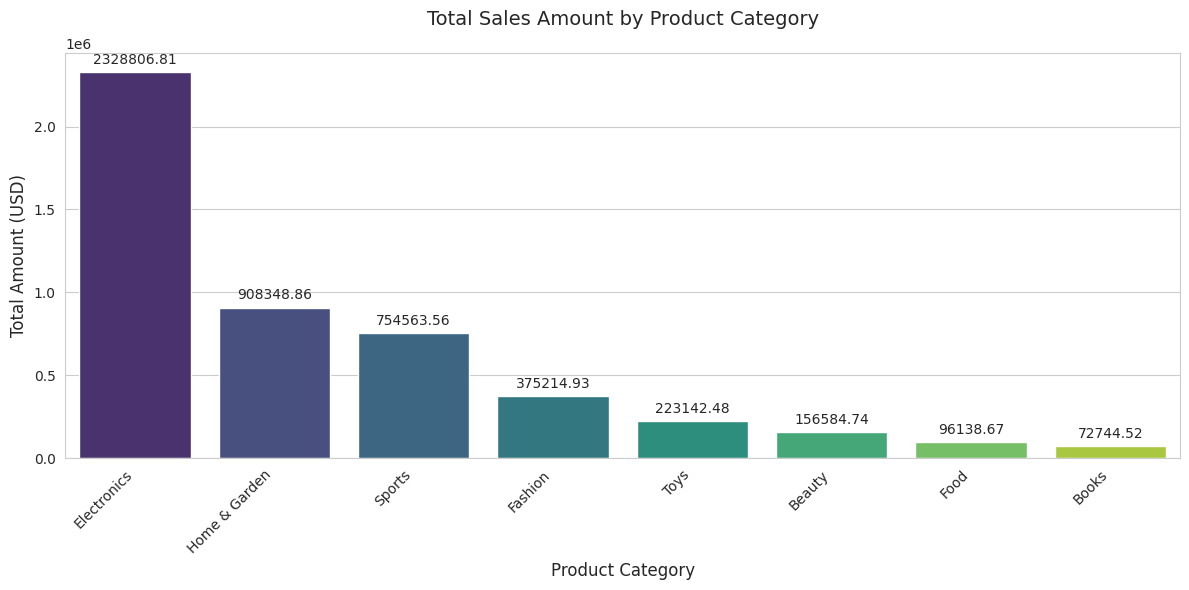

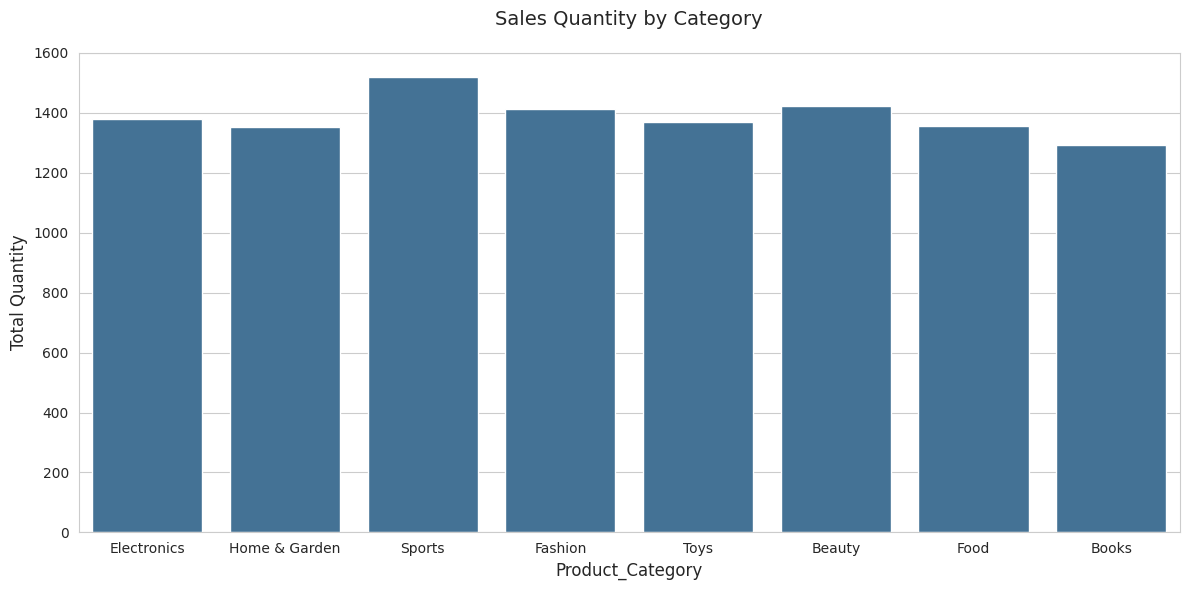

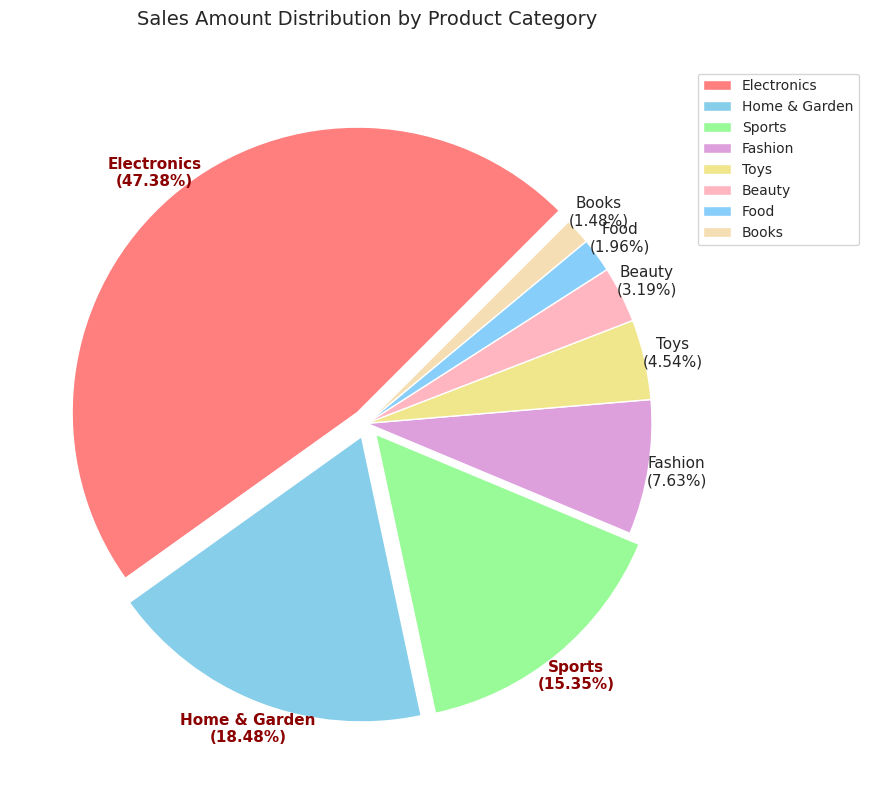

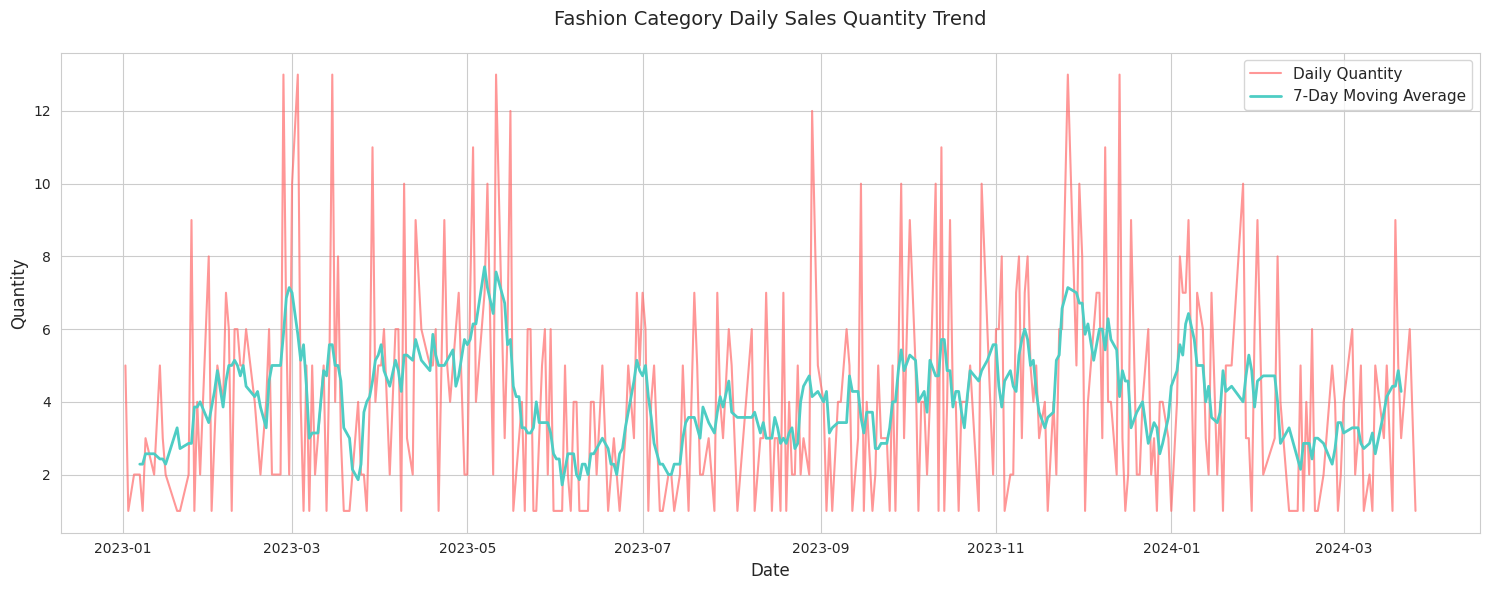

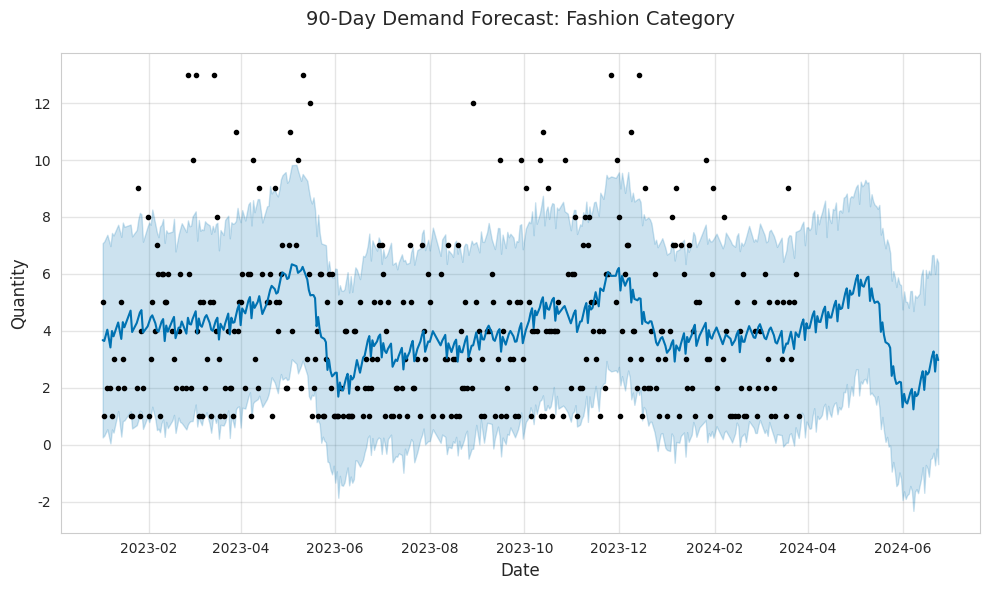

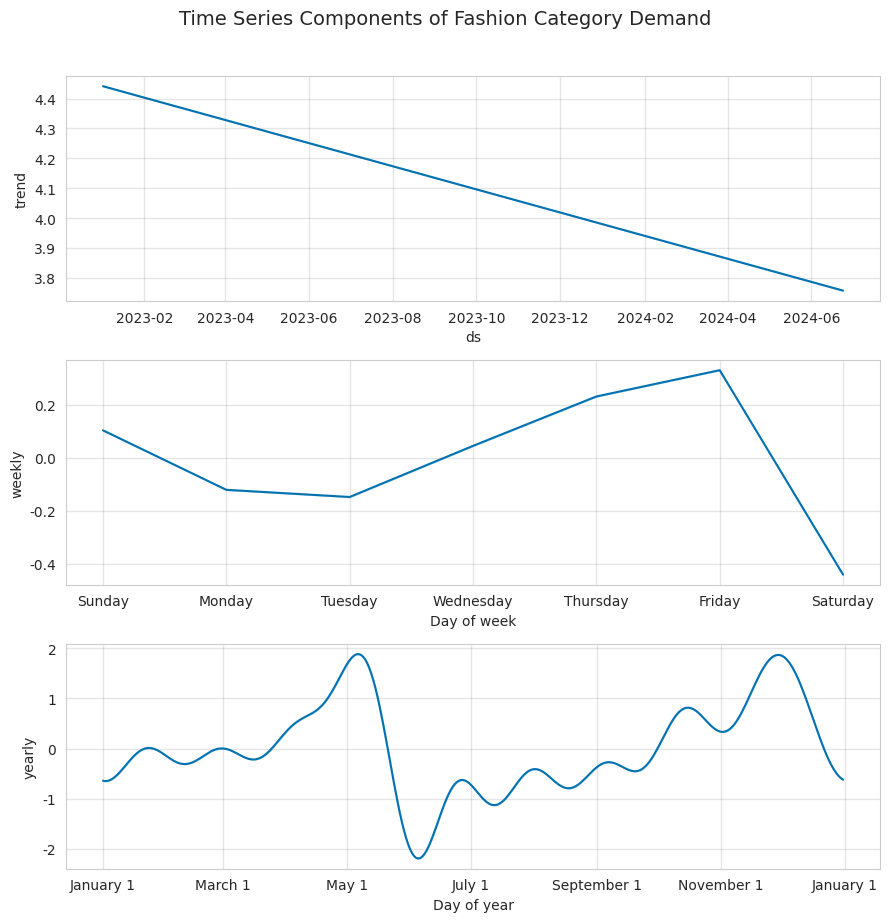

Prophet Model Performance Evaluation
RMSE: 2.67
R²: 0.10


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Files downloaded successfully (Colab)


In [5]:
# ==============================================
# Complete Code: Descriptive Analytics + Prophet Demand Forecasting
# Fixed Version: Includes your "Sales Quantity by Category" chart
# ==============================================

# 1. Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# 2. Set Visualization Style
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_style("whitegrid")

# 3. Load and Preprocess Data
df = pd.read_csv('sales_data_clean.csv')
df['Date'] = pd.to_datetime(df['Date'])

# 4. Basic Data Aggregation
category_analysis = df.groupby('Product_Category').agg({
    'Quantity': 'sum',
    'Total_Amount': 'sum'
}).sort_values(by='Total_Amount', ascending=False)

category_analysis['AOV'] = category_analysis['Total_Amount'] / category_analysis['Quantity']
category_analysis['Sales_Percent'] = (category_analysis['Total_Amount'] / category_analysis['Total_Amount'].sum()) * 100

# ==============================================
# Part 1: Descriptive Analytics - Core Charts
# ==============================================

# ---------- Chart 1: Total Sales Amount by Category ----------
plt.figure(figsize=(12, 6))
ax1 = sns.barplot(x=category_analysis.index, y=category_analysis['Total_Amount'], palette='viridis')
plt.title('Total Sales Amount by Product Category', fontsize=14, pad=20)
plt.ylabel('Total Amount (USD)', fontsize=12)
plt.xlabel('Product Category', fontsize=12)
plt.xticks(rotation=45, ha='right')
for i, v in enumerate(category_analysis['Total_Amount']):
    ax1.text(i, v + 50000, f'{v:.2f}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

# ---------- Chart 2: Sales Quantity by Category (Your original chart) ----------
# This is exactly the chart you provided: "Sales Quantity by Category"
plt.figure(figsize=(12, 6))
# Keep the original category order from your chart
category_order = ['Electronics', 'Home & Garden', 'Sports', 'Fashion', 'Toys', 'Beauty', 'Food', 'Books']
ax2 = sns.barplot(x=category_order, y=[category_analysis.loc[cat, 'Quantity'] for cat in category_order], color='#3674A3')
plt.title('Sales Quantity by Category', fontsize=14, pad=20)
plt.ylabel('Total Quantity', fontsize=12)
plt.xlabel('Product_Category', fontsize=12)
plt.xticks(rotation=0)  # Keep labels horizontal as in your original chart
plt.ylim(0, 1600)
plt.tight_layout()
plt.show()

# ---------- Chart 3: Sales Amount Distribution Pie Chart ----------
plt.figure(figsize=(12, 8))
colors = ['#FF7F7F', '#87CEEB', '#98FB98', '#DDA0DD', '#F0E68C', '#FFB6C1', '#87CEFA', '#F5DEB3']
sales_percent = category_analysis['Sales_Percent'].round(2)
labels = [f'{cat}\n({pct}%)' for cat, pct in zip(category_analysis.index, sales_percent)]
explode = [0.05 if p > 10 else 0 for p in sales_percent]

patches, texts, autotexts = plt.pie(
    sales_percent,
    labels=labels,
    autopct='',
    explode=explode,
    colors=colors,
    startangle=45,
    textprops={'fontsize': 11, 'ha': 'center'},
    labeldistance=1.1
)

for i, text in enumerate(texts):
    if sales_percent.iloc[i] > 10:
        text.set_fontweight('bold')
        text.set_color('darkred')

plt.title('Sales Amount Distribution by Product Category', fontsize=14, pad=30)
plt.tight_layout()
plt.legend(patches, category_analysis.index, loc='upper right', bbox_to_anchor=(1.2, 1))
plt.show()

# ---------- Chart 4: Fashion Category Daily Sales Trend ----------
fashion_df = df[df['Product_Category'] == 'Fashion'].groupby('Date').agg({'Quantity': 'sum'}).reset_index()
fashion_df['7D_MA'] = fashion_df['Quantity'].rolling(window=7, center=True).mean()

plt.figure(figsize=(15, 6))
sns.lineplot(x='Date', y='Quantity', data=fashion_df, label='Daily Quantity', color='#FF6B6B', alpha=0.7)
sns.lineplot(x='Date', y='7D_MA', data=fashion_df, label='7-Day Moving Average', color='#4ECDC4', linewidth=2)
plt.title('Fashion Category Daily Sales Quantity Trend', fontsize=14, pad=20)
plt.ylabel('Quantity', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

# ==============================================
# Part 2: Prophet Demand Forecasting (Your original 3 charts)
# ==============================================

# Prepare Prophet data
fashion_df_prophet = df[df['Product_Category'] == 'Fashion'].groupby('Date').agg({'Quantity': 'sum'}).reset_index()
prophet_df = fashion_df_prophet.rename(columns={'Date': 'ds', 'Quantity': 'y'})

# Train Prophet model
model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model.fit(prophet_df)

# 90-day forecast
future = model.make_future_dataframe(periods=90)
forecast = model.predict(future)

# ---------- Chart 5: Prophet 90-Day Demand Forecast ----------
fig1 = model.plot(forecast)
plt.title('90-Day Demand Forecast: Fashion Category', fontsize=14, pad=20)
plt.ylabel('Quantity', fontsize=12)
plt.xlabel('Date', fontsize=12)
plt.tight_layout()
plt.show()

# ---------- Chart 6: Prophet Time Series Components ----------
fig2 = model.plot_components(forecast)
plt.suptitle('Time Series Components of Fashion Category Demand', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ==============================================
# Model Performance Evaluation
# ==============================================
y_true = prophet_df['y'].values
y_pred = forecast.iloc[:len(y_true)]['yhat'].values
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print("="*60)
print("Prophet Model Performance Evaluation")
print("="*60)
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")
print("="*60)

# ==============================================
# Export Results
# ==============================================
category_analysis.to_csv('category_analysis_summary.csv', index=True)
forecast_output = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(90)
forecast_output.to_csv('fashion_demand_forecast_90days.csv', index=False)

try:
    from google.colab import files
    files.download('category_analysis_summary.csv')
    files.download('fashion_demand_forecast_90days.csv')
    print("\nFiles downloaded successfully (Colab)")
except ImportError:
    print("\nFiles saved to current directory (Local)")